In [1]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

In [2]:
# ============================================================
# CELL 2: Load Data + Basic Info
# ============================================================
df = pd.read_csv(r"C:\Users\admin\Downloads\archive (1)\Concrete_Data.csv")   # <-- update filename/path as needed

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

Shape of dataset: (1030, 9)

First 5 rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30



Data types:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object

Missing values per column:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine A

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [3]:
# ============================================================
# CELL 3: Clean Data — Nulls + Outliers (IQR method)
# ============================================================
print("Rows before cleaning:", df.shape[0])

# --- Handle missing values ---
df = df.dropna().reset_index(drop=True)
print("Rows after dropping nulls:", df.shape[0])

# --- Outlier removal using IQR method (all numeric columns) ---
rows_before_outlier_removal = df.shape[0]

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df = df.reset_index(drop=True)

print("Rows before outlier removal:", rows_before_outlier_removal)
print("Rows after outlier removal:", df.shape[0])
print("Total rows removed:", rows_before_outlier_removal - df.shape[0])

Rows before cleaning: 1030
Rows after dropping nulls: 1030
Rows before outlier removal: 1030
Rows after outlier removal: 926
Total rows removed: 104


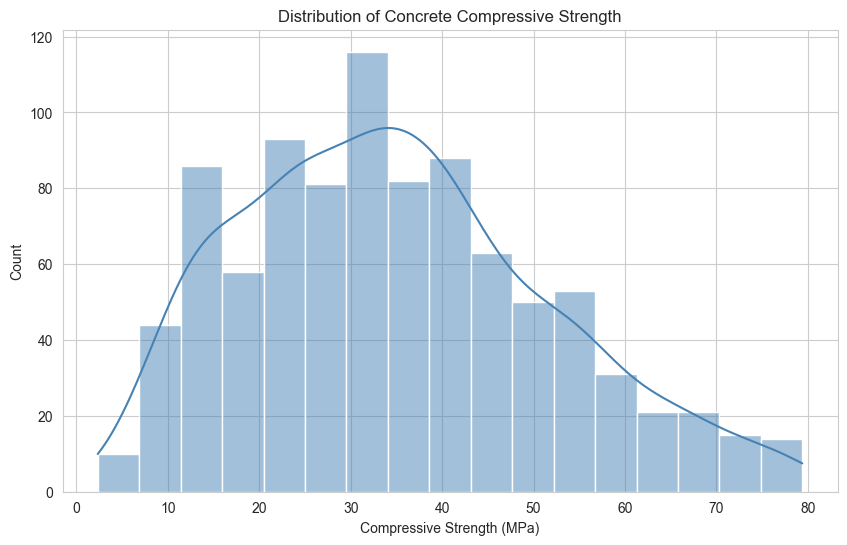

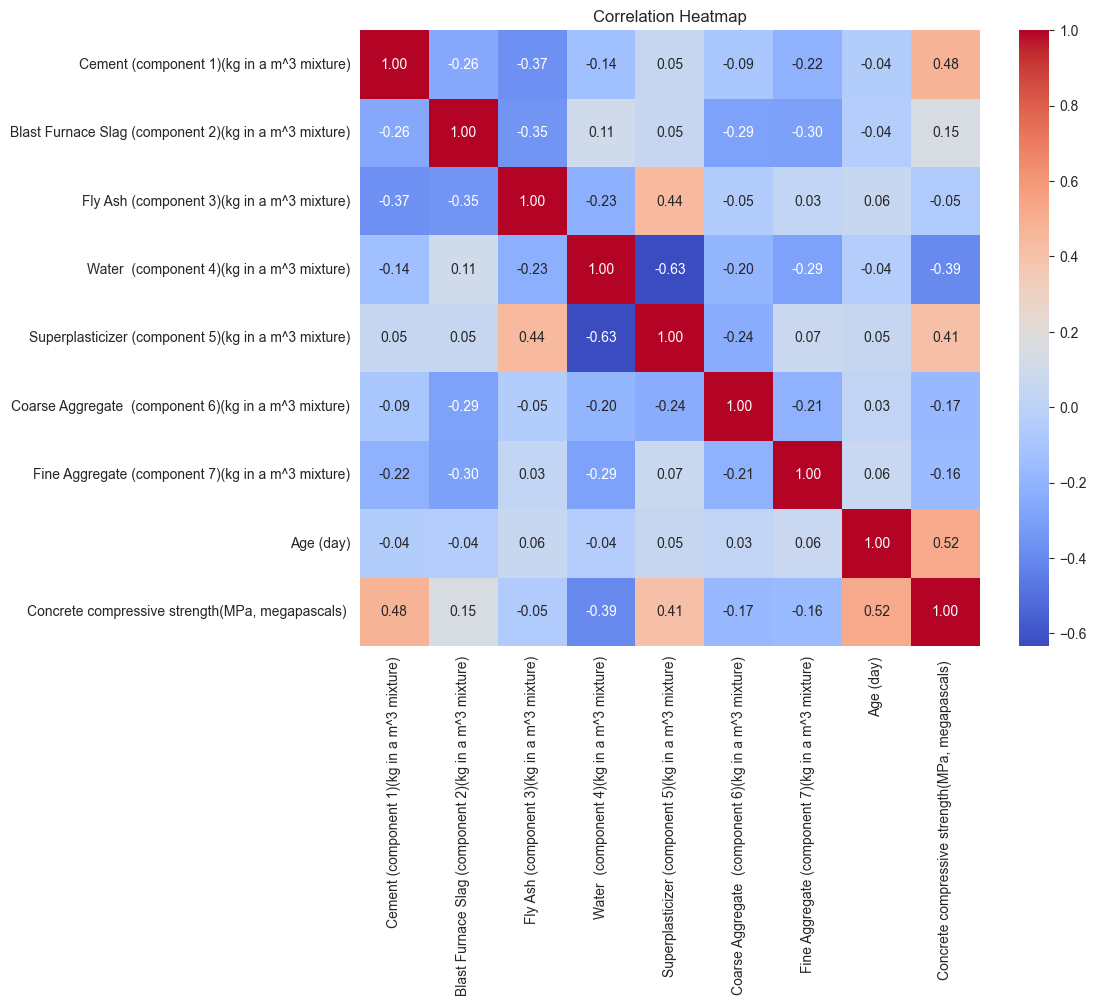

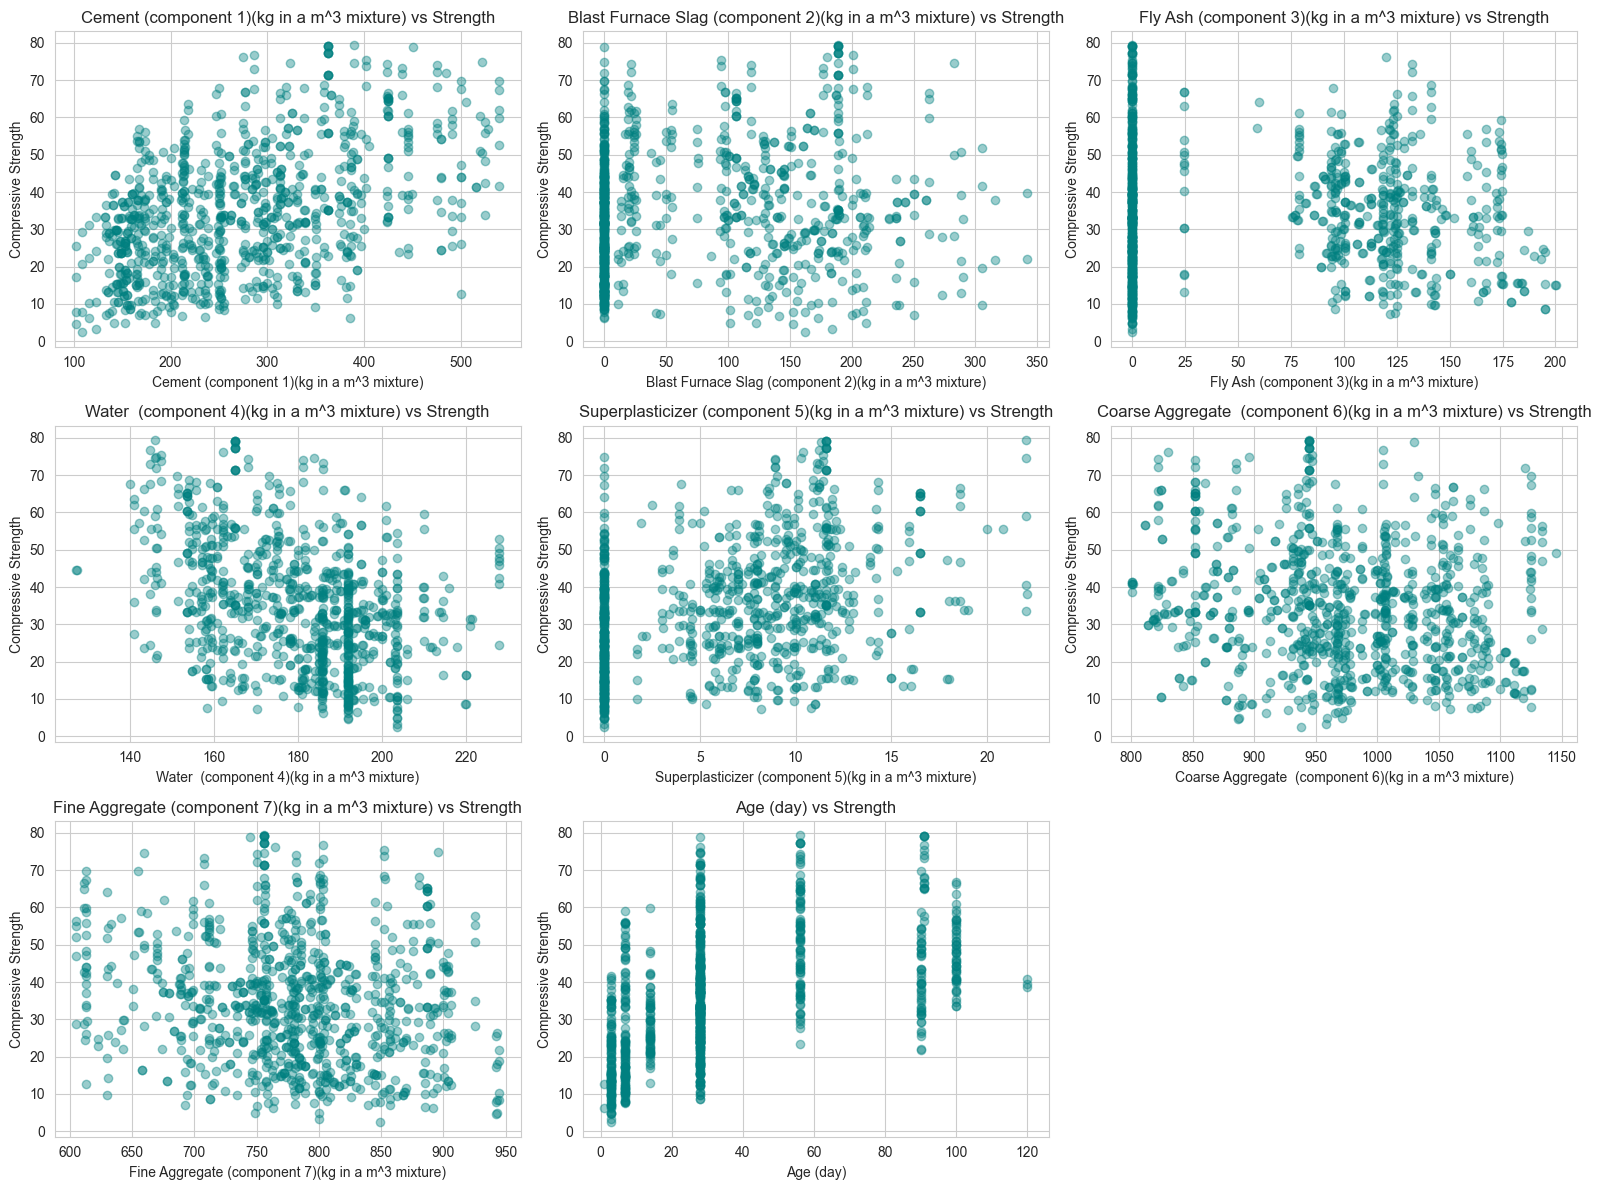

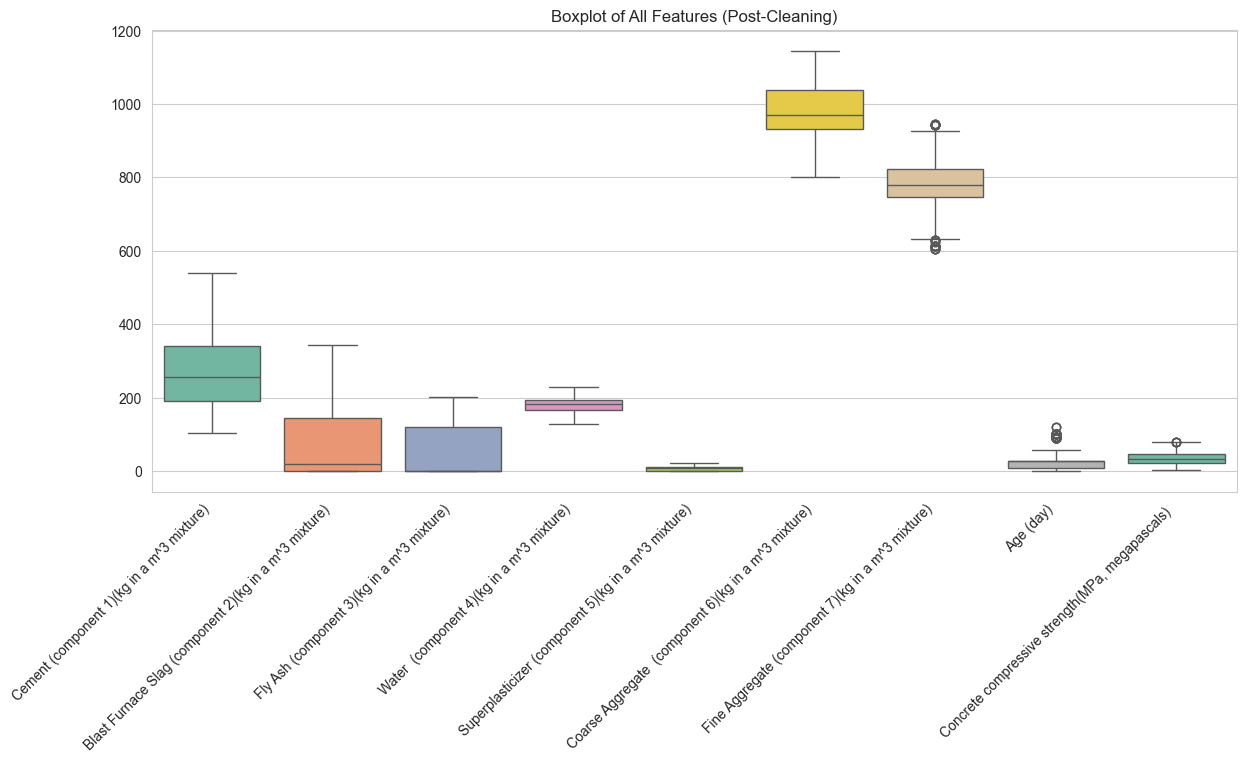

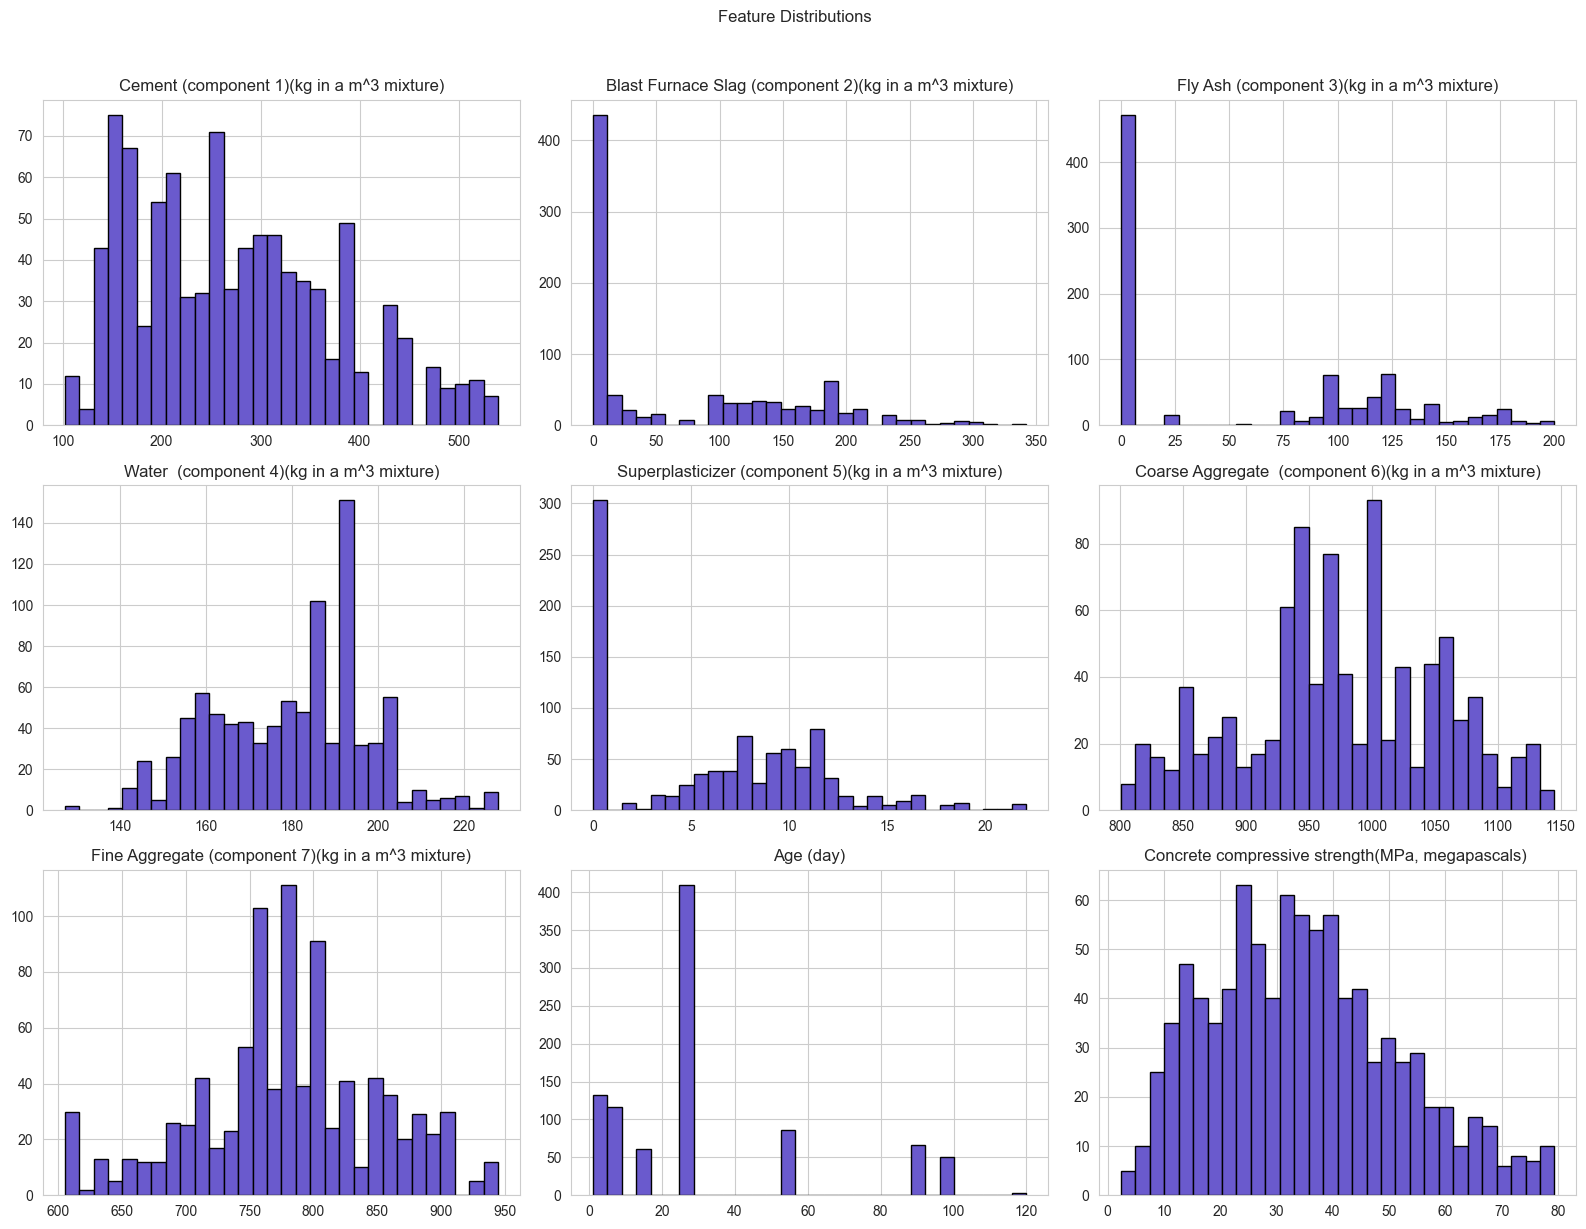

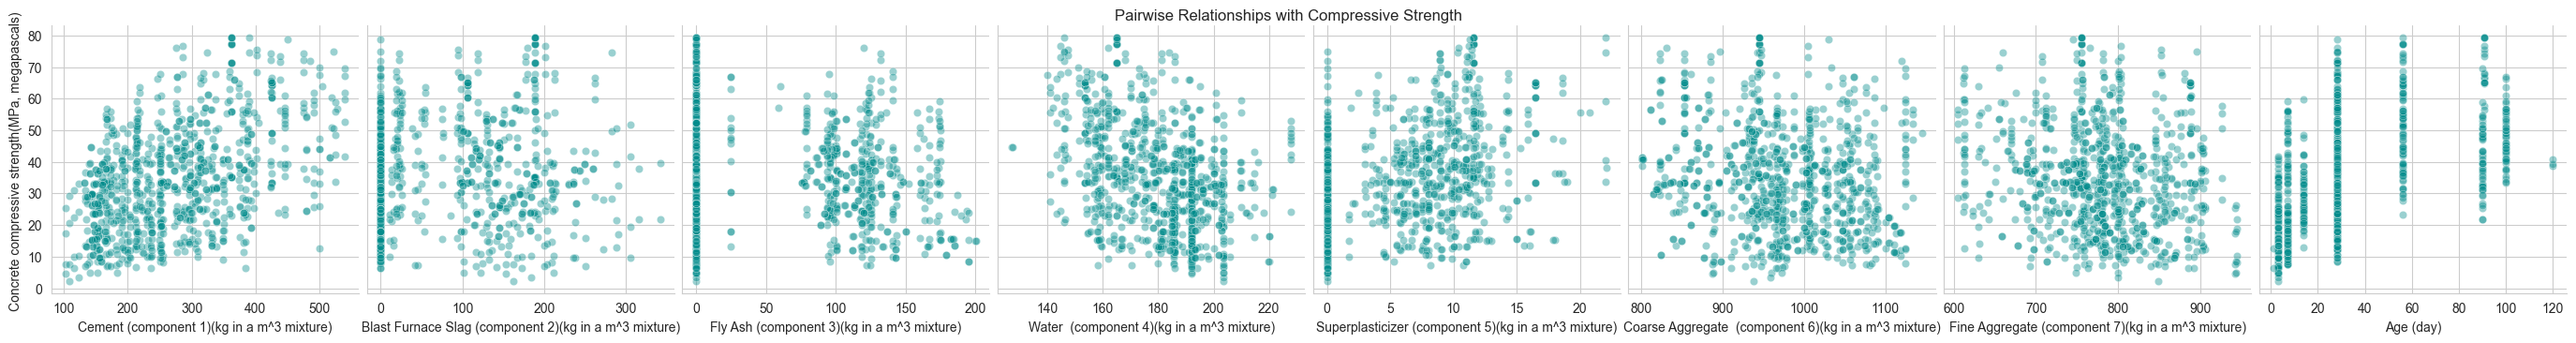

In [4]:
# ============================================================
# CELL 4: Visualization
# ============================================================
target_col = "Concrete compressive strength(MPa, megapascals) "
feature_cols = [c for c in df.columns if c != target_col]

# --- Distribution of target ---
plt.figure()
sns.histplot(df[target_col], kde=True, color="steelblue")
plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Compressive Strength (MPa)")
plt.show()

# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# --- Scatter plots: each feature vs target ---
n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df[target_col], alpha=0.4, color="teal")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Compressive Strength")
    axes[i].set_title(f"{col} vs Strength")

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- Boxplots for all features (post-cleaning) ---
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, palette="Set2")
plt.title("Boxplot of All Features (Post-Cleaning)")
plt.xticks(rotation=45, ha="right")
plt.show()

# --- Histograms for all features ---
df.hist(figsize=(16, 12), bins=30, color="slateblue", edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# --- Pairplot ---
sns.pairplot(df, y_vars=[target_col], x_vars=feature_cols, height=3.5,
             plot_kws={"color": "darkcyan", "alpha": 0.4})
plt.suptitle("Pairwise Relationships with Compressive Strength", y=1.02)
plt.show()

In [5]:
# ============================================================
# CELL 5: Train-Test Split + Feature Scaling
# ============================================================
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (740, 8)
X_test shape: (186, 8)


In [6]:
# ============================================================
# CELL 6: Train & Compare Models
# ============================================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train R2": train_r2, "Test R2": test_r2,
        "Train RMSE": train_rmse, "Test RMSE": test_rmse,
        "Train MAE": train_mae, "Test MAE": test_mae
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print("Model Comparison Table:")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest Model: {best_model_name}")

Model Comparison Table:


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,XGBoost,0.994521,0.908251,1.204867,5.492039,0.380655,3.632858
1,Random Forest,0.983846,0.894812,2.068902,5.880540,1.298105,4.216203
2,Gradient Boosting,0.949306,0.887815,3.665024,6.072959,2.745361,4.257979
3,Linear Regression,0.766049,0.792311,7.873371,8.263043,6.092550,6.386063
4,Ridge,0.766040,0.792032,7.873527,8.268588,6.092125,6.391842
5,Lasso,0.732216,0.750550,8.423468,9.055773,6.644351,7.083244



Best Model: XGBoost


Best Model: XGBoost
Train R2: 0.9945 | Test R2: 0.9083
Train RMSE: 1.2049 | Test RMSE: 5.4920


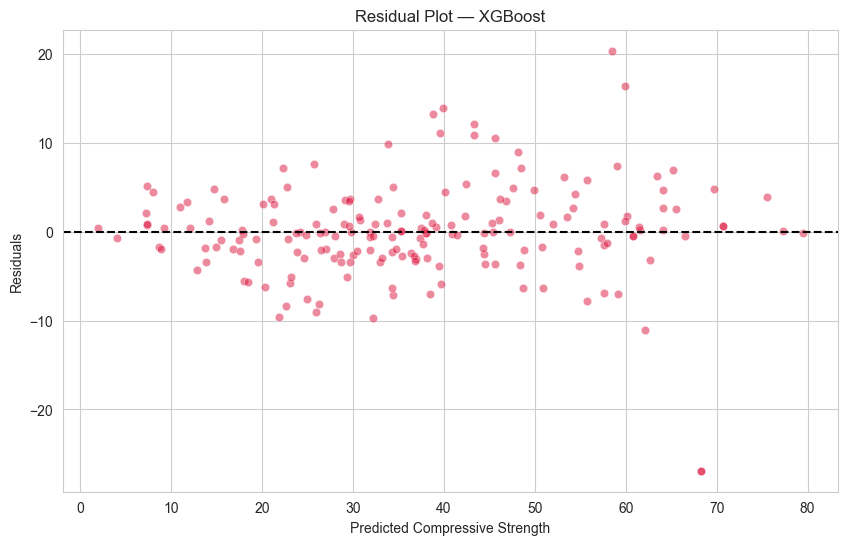

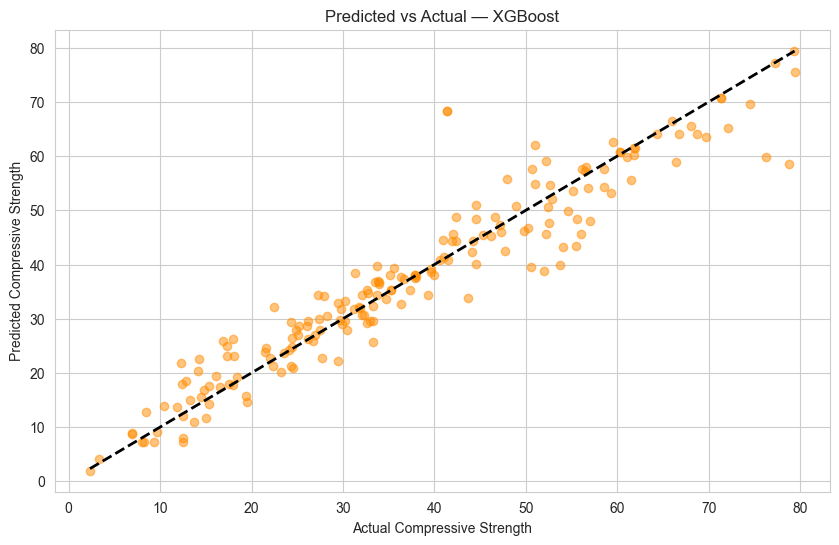


--- VERDICT ---
Good fit: Train R2 (0.9945) and Test R2 (0.9083) are close and reasonably high.


In [7]:
# ============================================================
# CELL 7: Overfitting/Underfitting Evaluation — Best Model
# ============================================================
y_train_pred_best = best_model.predict(X_train_scaled)
y_test_pred_best = best_model.predict(X_test_scaled)

train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Best Model: {best_model_name}")
print(f"Train R2: {train_r2_best:.4f} | Test R2: {test_r2_best:.4f}")
print(f"Train RMSE: {train_rmse_best:.4f} | Test RMSE: {test_rmse_best:.4f}")

r2_gap = train_r2_best - test_r2_best

# --- Residual Plot ---
residuals = y_test - y_test_pred_best
plt.figure()
sns.scatterplot(x=y_test_pred_best, y=residuals, color="crimson", alpha=0.5)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Compressive Strength")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

# --- Predicted vs Actual Plot ---
plt.figure()
plt.scatter(y_test, y_test_pred_best, alpha=0.5, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Compressive Strength")
plt.ylabel("Predicted Compressive Strength")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

# --- Verdict ---
print("\n--- VERDICT ---")
if r2_gap > 0.1:
    print(f"Overfitting detected: Train R2 ({train_r2_best:.4f}) is notably higher than Test R2 ({test_r2_best:.4f}).")
elif train_r2_best < 0.6 and test_r2_best < 0.6:
    print(f"Underfitting detected: Both Train R2 ({train_r2_best:.4f}) and Test R2 ({test_r2_best:.4f}) are low.")
else:
    print(f"Good fit: Train R2 ({train_r2_best:.4f}) and Test R2 ({test_r2_best:.4f}) are close and reasonably high.")

In [8]:
# ============================================================
# CELL 8: Test Best Model on 5 Random Test Rows
# ============================================================
sample_idx = np.random.choice(X_test.index, size=5, replace=False)

sample_X = X_test.loc[sample_idx]
sample_y_actual = y_test.loc[sample_idx]
sample_X_scaled = scaler.transform(sample_X)
sample_y_pred = best_model.predict(sample_X_scaled)

sample_results = pd.DataFrame({
    "Actual": sample_y_actual.values,
    "Predicted": sample_y_pred,
})
sample_results["Error %"] = ((sample_results["Predicted"] - sample_results["Actual"]).abs()
                              / sample_results["Actual"]) * 100

print(f"Sample Predictions using {best_model_name}:")
display(sample_results)

Sample Predictions using XGBoost:


,Actual,Predicted,Error %
0,26.05,28.562527,9.645016
1,32.11,30.773890,4.161042
2,51.02,62.067322,21.652924
3,2.33,1.945384,16.507128
4,30.23,29.554890,2.233246


In [9]:
# ============================================================
# CELL 9: Manual Input Prediction
# ============================================================
print("Enter values for prediction:")
cement = float(input("Cement (kg in a m^3 mixture): "))
blast_slag = float(input("Blast Furnace Slag (kg in a m^3 mixture): "))
fly_ash = float(input("Fly Ash (kg in a m^3 mixture): "))
water = float(input("Water (kg in a m^3 mixture): "))
superplasticizer = float(input("Superplasticizer (kg in a m^3 mixture): "))
coarse_agg = float(input("Coarse Aggregate (kg in a m^3 mixture): "))
fine_agg = float(input("Fine Aggregate (kg in a m^3 mixture): "))
age = float(input("Age (day): "))

manual_input = pd.DataFrame([{
    "Cement (component 1)(kg in a m^3 mixture)": cement,
    "Blast Furnace Slag (component 2)(kg in a m^3 mixture)": blast_slag,
    "Fly Ash (component 3)(kg in a m^3 mixture)": fly_ash,
    "Water  (component 4)(kg in a m^3 mixture)": water,
    "Superplasticizer (component 5)(kg in a m^3 mixture)": superplasticizer,
    "Coarse Aggregate  (component 6)(kg in a m^3 mixture)": coarse_agg,
    "Fine Aggregate (component 7)(kg in a m^3 mixture)": fine_agg,
    "Age (day)": age
}])

manual_input_scaled = scaler.transform(manual_input)
manual_pred = best_model.predict(manual_input_scaled)

print(f"\nPredicted Concrete Compressive Strength: {manual_pred[0]:.4f} MPa")

Enter values for prediction:


Cement (kg in a m^3 mixture):  540
Blast Furnace Slag (kg in a m^3 mixture):  0
Fly Ash (kg in a m^3 mixture):  0
Water (kg in a m^3 mixture):  162
Superplasticizer (kg in a m^3 mixture):  2.5
Coarse Aggregate (kg in a m^3 mixture):  1040
Fine Aggregate (kg in a m^3 mixture):  676
Age (day):  28



Predicted Concrete Compressive Strength: 63.4133 MPa


In [10]:
# ============================================================
# CELL 10: Save Trained Model and Scaler
# ============================================================
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Saved best model ({best_model_name}) as 'best_model.pkl'")
print("Saved scaler as 'scaler.pkl'")

Saved best model (XGBoost) as 'best_model.pkl'
Saved scaler as 'scaler.pkl'
